In [1]:
#import libraries
import numpy as np
from helper_ft import *#import helper functions
import helper_ft as hf
import list as lst
%load_ext autoreload
%aimport helper_ft
%autoreload 1

In [ ]:
def load_header(path):
    """Load column names from CSV header.
    path: path to CSV file
    return: list of column names in the header
    """
    with open(path, 'r') as f:
        header = f.readline().strip()
    return header.split(',')

def match_col_names(partial_names, header):
    """
    Match partial column names with full column names from the header.
    partial_names: list of partial column names to match
    header: list of all column names
    return: list of matched full column names
    """
    matched_names = []
    for pname in partial_names:
        for hname in header:
            if hname == pname:
                matched_names.append(hname)
                break
            elif hname.startswith(pname):
                matched_names.append(hname)
                break
            elif hname == f"_{pname}":
                matched_names.append(hname)
                break
    return matched_names

def get_col_index(cols, header):
    """Get the index of a column given its name from a list of column names.
    cols: list of column names to find
    header: list of all column names
    """
    #check name for name, if not found print an error message with the name not found and continue adding the found columns
    for name in cols:
        if name not in header:
            print(f"Column '{name}' not found in the provided list.")
    return [name for name in cols if name in header], [header.index(name) for name in cols if name in header]

def load_data_col(path, cols=(0), has_header=True):
    """Load numeric CSV with missing values -> np.nan using only numpy.
    path: path to CSV file
    cols: list of column indices to load (default: 0)
    has_header: whether the CSV file has a header row (default: True)

    returns data with nan for missing values
    """
    skip = 1 if has_header else 0
    data = np.genfromtxt(
        path,
        delimiter=",",
        skip_header=1 if has_header else 0,
        usecols=(cols),  # adjust based on relevant columns]       # force float to accommodate np.nan
        missing_values=["", "NA", "NaN"],       # treat empty strings as missing missing_values=["", "NA", "NaN"]
        filling_values=np.nan,
        autostrip=True,
        invalid_raise=False
    )
    return data

def expand_column(col, col_name):
    '''
    Expand a 1D column vector into a N array where N is the number of unique values in col.
    Each column in the output array is a binary indicator (0 or 1) of whether the corresponding
    entry in col matches the unique value for that column.
    col: 1D numpy array of categorical values

    #Missing values are handled by adding an additional binary indicator column and set to 0.
    '''
    is_missing = np.isnan(col).astype(np.int8)
    has_missing = np.any(is_missing)

    col = np.where(is_missing, 0, col)

    unique_values = np.unique(col)

    if unique_values.size > 10 and not has_missing:
        return None, None
    elif unique_values.size > 10 and has_missing:
        expanded = np.column_stack([col, is_missing])
        col_names = [f"{col_name}_is_missing"]
    else:
        #print(f"Unique values in column '{col_name}': {unique_values}")
        expanded = np.zeros((col.size, unique_values.size), dtype=np.int16)
        for i, val in enumerate(unique_values):
            expanded[:, i] = (col == val).astype(int)
        col_names = [f"{col_name}_{val}" for val in unique_values]

        if has_missing:
            expanded = np.column_stack([expanded, is_missing])
            col_names.append(f"{col_name}_is_missing")

    return expanded, col_names


def expand_dataset_col(col_list, path):
    '''
    Expand a dataset by selecting specific columns and expanding categorical columns into binary indicators.
    col_list: list of column names to select and expand
    header: list of all column names in the dataset
    dataset: numpy array of the dataset to expand or path to the dataset
    return: expanded dataset as a numpy array and list of new column names
    '''
    path_dataset = path
    header = load_header(path_dataset)
    print("Original col_list:", col_list)
    print("Header:", header)
    col_list = match_col_names(col_list, header)

    col_name, col_index = get_col_index(col_list, header)
    print(col_index)
    dataset = load_data_col(path_dataset, cols=col_index)
    header = load_header(path_dataset)
    x_train_subset = dataset
   
    col_list = match_col_names(col_list, header)
    print("Matched col_list:", col_list)
    col_list, col_index = get_col_index(col_list, header)
    print(len(col_index))
    #load x_train with only the columns in col_indices
    
    expanded_cols = []
    expanded_col_names = []
    for i, col_name in enumerate(col_list):
        expanded_col, col_names = expand_column(x_train_subset[:, i], col_name)
        if expanded_col is None:
            print(f"Skipping column '{col_name}' due to too many unique values.")
            continue
        expanded_cols.append(expanded_col)
        expanded_col_names.extend(col_names)
    return np.hstack(expanded_cols), expanded_col_names


In [133]:
dataset = load_data_col('../data/dataset/x_train.csv', cols=265)


In [ ]:
np(dataset)

array([0.0000e+00, 2.3000e+01, 4.7000e+01, 7.0000e+01, 9.3000e+01,
       1.0000e+02, 1.1700e+02, 1.4000e+02, 1.6300e+02, 1.8700e+02,
       2.0000e+02, 2.1000e+02, 2.3300e+02, 2.5700e+02, 2.8000e+02,
       3.0000e+02, 3.0300e+02, 3.2700e+02, 3.5000e+02, 3.7300e+02,
       3.9700e+02, 4.0000e+02, 4.2000e+02, 4.4300e+02, 4.6700e+02,
       4.9000e+02, 5.0000e+02, 5.1300e+02, 5.3700e+02, 5.6000e+02,
       5.8300e+02, 6.0000e+02, 6.0700e+02, 6.3000e+02, 6.5300e+02,
       6.7700e+02, 7.0000e+02, 7.4700e+02, 7.7000e+02, 7.9300e+02,
       8.0000e+02, 8.1700e+02, 8.4000e+02, 8.8700e+02, 9.0000e+02,
       9.1000e+02, 9.3300e+02, 9.8000e+02, 1.0000e+03, 1.0270e+03,
       1.0500e+03, 1.0730e+03, 1.1200e+03, 1.1430e+03, 1.1670e+03,
       1.1900e+03, 1.2000e+03, 1.2130e+03, 1.2600e+03, 1.2830e+03,
       1.3000e+03, 1.3070e+03, 1.3300e+03, 1.3530e+03, 1.4000e+03,
       1.4700e+03, 1.4930e+03, 1.5000e+03, 1.5170e+03, 1.5400e+03,
       1.5870e+03, 1.6000e+03, 1.6100e+03, 1.6330e+03, 1.6800e

In [93]:
y_full = load_data_col('../data/dataset/y_train.csv', cols=(1))

In [ ]:
import numpy as np

def build_k_indices(y, k_fold, seed):
    """build k indices for k-fold.

    Args:
        y:      shape=(N,)
        k_fold: K in K-fold, i.e. the fold num
        seed:   the random seed

    Returns:
        A 2D array of shape=(k_fold, N/k_fold) that indicates the data indices for each fold

    >>> build_k_indices(np.array([1., 2., 3., 4.]), 2, 1)
    array([[3, 2],
           [0, 1]])
    """
    num_row = y.shape[0]
    interval = int(num_row / k_fold)
    np.random.seed(seed)
    indices = np.random.permutation(num_row)
    k_indices = [indices[k * interval : (k + 1) * interval] for k in range(k_fold)]
    return np.array(object=k_indices, dtype=int)

# def build_stratified_k_indices(y, k_fold, seed=42):
#     """
#     Build stratified k indices for k-fold CV.

#     Ensures each fold has roughly the same class distribution as the original data.

#     Args:
#         y: numpy array of shape (N,)
#         k_fold: number of folds
#         seed: random seed
#     Returns:
#         folds: list of length k_fold, each element is an array of indices
#     """
#     np.random.seed(seed)

#     # 1️⃣ Get unique classes and their indices
#     classes = np.unique(y)
#     class_indices = [np.where(y == c)[0] for c in classes]

#     # 2️⃣ Shuffle indices of each class separately
#     for idx in class_indices:
#         np.random.shuffle(idx)

#     # 3️⃣ Split each class into k roughly equal parts
#     class_folds = [np.array_split(idx, k_fold) for idx in class_indices]

#     # 4️⃣ Combine one part from each class into each fold
#     folds = []
#     for k in range(k_fold):
#         fold_indices = np.concatenate([cf[k] for cf in class_folds])
#         np.random.shuffle(fold_indices)  # optional: shuffle inside fold
#         folds.append(fold_indices)

#     return np.array(folds, dtype=object)


In [107]:
k_fold = 5
seed = 10
k_indices = build_k_indices(y_full, k_fold, seed)


In [127]:
import numpy as np

def max_ratio_deviation(y, k_indices):
    vals, cnts = np.unique(y, return_counts=True)
    overall = dict(zip(vals, cnts / cnts.sum()))
    worst = 0.0
    for idx in k_indices:
        v, c = np.unique(y[idx], return_counts=True)
        r = dict(zip(v, c / c.sum()))
        for cls, r_overall in overall.items():
            worst = max(worst, abs(r.get(cls, 0.0) - r_overall))
    return worst

k_fold = 5
NTEST = 50
worsts = []
for seed in range(1, NTEST+1):
    k_idx = build_k_indices(y_full, k_fold, seed)
    worsts.append(max_ratio_deviation(y_full, k_idx))

print(f"Over {NTEST} seeds:")
print(f"  mean worst deviation per seed: {np.mean(worsts):.4%}")
print(f"  max worst deviation observed  : {np.max(worsts):.4%}")


Over 50 seeds:
  mean worst deviation per seed: 0.1548%
  max worst deviation observed  : 0.3124%


In [120]:
k_indices[0]

array([124267, 239557, 126681, ..., 222040,  92691,  36866],
      shape=(65627,))

In [121]:
k_indices[1]

array([ 25273,  73307,  29891, ..., 227024, 191963, 325039],
      shape=(65627,))

In [118]:
np.sum(y_full[k_indices[4]] == 1)


np.int64(5864)

In [119]:
np.sum(y_full[k_indices[4]] == -1)


np.int64(59763)

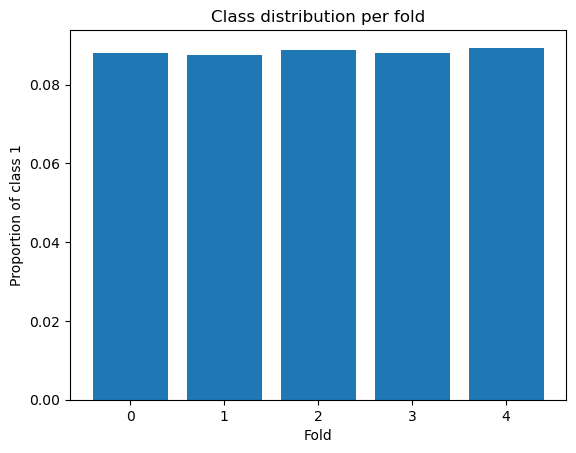

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# assuming y is your labels array and k_indices is from build_stratified_k_indices
ratios = [np.mean(y_full[fold] == 1) for fold in k_indices]

plt.bar(range(len(k_indices)), ratios)
plt.xlabel("Fold")
plt.ylabel("Proportion of class 1")
plt.title("Class distribution per fold")
plt.show()


In [89]:
np.sum(y_train_full == 1)


np.int64(28975)

In [49]:
dataset.shape

(328135,)

In [36]:
du = 0

In [37]:
np.any(du)

np.False_

In [132]:
dataset

array([nan, nan, nan, ..., nan, nan,  6.], shape=(328135,))

In [51]:
for x in range(20):
    print(f'x: {x}, dataset[x]: {dataset[x]}')

x: 0, dataset[x]: nan
x: 1, dataset[x]: nan
x: 2, dataset[x]: nan
x: 3, dataset[x]: nan
x: 4, dataset[x]: nan
x: 5, dataset[x]: nan
x: 6, dataset[x]: nan
x: 7, dataset[x]: nan
x: 8, dataset[x]: nan
x: 9, dataset[x]: nan
x: 10, dataset[x]: nan
x: 11, dataset[x]: nan
x: 12, dataset[x]: nan
x: 13, dataset[x]: nan
x: 14, dataset[x]: nan
x: 15, dataset[x]: 99.0
x: 16, dataset[x]: nan
x: 17, dataset[x]: nan
x: 18, dataset[x]: nan
x: 19, dataset[x]: 1.0


In [128]:
col_list = lst.col_list[:2]
col_list.append('_DRNKWEK')
col_list

['_RFHLTH', '_HCVU651', '_DRNKWEK']

In [129]:

x_train_expanded, expanded_col_names = expand_dataset_col(col_list, '../data/dataset/x_train.csv')


Original col_list: ['_RFHLTH', '_HCVU651', '_DRNKWEK']
Header: ['Id', '_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE', 'HHADULT', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', 'TOLDHI2', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'DIABAGE2', 'SEX', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME2', 'INTERNET', 'WEIGHT2', 'HEIGHT3', 'PREGNANT', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'USENOW3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'FRUIT1'

In [130]:
import pandas as pd

<function __main__.expand_dataset_col(col_list, path)>

In [131]:
pd_data = pd.DataFrame(x_train_expanded, columns=expanded_col_names)
pd_data.head(20)

,_RFHLTH_1.0,_RFHLTH_2.0,_RFHLTH_9.0,_HCVU651_1.0,_HCVU651_2.0,_HCVU651_9.0
0,1,0,0,1,0,0
1,0,1,0,1,0,0
2,1,0,0,0,0,1
3,1,0,0,0,0,1
4,1,0,0,0,0,1
5,1,0,0,1,0,0
6,0,1,0,0,0,1
7,1,0,0,0,0,1
8,1,0,0,1,0,0
9,1,0,0,1,0,0


In [61]:
pd_data.columns

Index(['_RFHLTH_1.0', '_RFHLTH_2.0', '_RFHLTH_9.0', '_RFHLTH_is_missing',
       '_HCVU651_1.0', '_HCVU651_2.0', '_HCVU651_9.0', '_HCVU651_is_missing'],
      dtype='object')

In [12]:
expanded_col_names

['_RFHLTH_1.0',
 '_RFHLTH_2.0',
 '_RFHLTH_9.0',
 '_HCVU651_1.0',
 '_HCVU651_2.0',
 '_HCVU651_9.0']

In [13]:
x_train_expanded.shape

(328135, 6)